# 混凝土抗压强度预测（Yeh 数据集）

本 notebook 完成以下任务：
1. 数据读取与基本检查（1030 条样本，8 个输入特征，1 个输出）。
2. 按顺序将前 80% 作为训练集，后 20% 作为测试集。
3. 数据预处理（缺失值处理 + 标准化）。
4. 特征分析：相关性分析 + PCA。
5. 建模与评估：线性回归、PyTorch 神经网络。
6. 使用测试集 MSE/RMSE/R2 评估，并绘制可视化图。

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [31]:
df = pd.read_csv("Concrete_Data_Yeh.csv")

print(f"数据形状: {df.shape}")
display(df.head())

print("列名:")
print(df.columns.tolist())

数据形状: (1030, 9)


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


列名:
['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age', 'csMPa']


In [32]:
target_col = "csMPa"
feature_cols = [c for c in df.columns if c != target_col]
df_shuffled = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
split_idx = int(len(df_shuffled) * 0.8)
train_df = df_shuffled.iloc[:split_idx].copy()
test_df = df_shuffled.iloc[split_idx:].copy()

print(f"训练集大小: {train_df.shape}")
print(f"测试集大小: {test_df.shape}")

print("\n训练集缺失值统计:")
display(train_df.isna().sum())
print("测试集缺失值统计:")
display(test_df.isna().sum())

X_train_raw = train_df[feature_cols]
y_train = train_df[target_col].values
X_test_raw = test_df[feature_cols]
y_test = test_df[target_col].values

# 缺失值处理（即使当前无缺失，也保留完整流程）
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

训练集大小: (824, 9)
测试集大小: (206, 9)

训练集缺失值统计:


cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

测试集缺失值统计:


cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

## 1) 相关性分析（Feature Selection）

在训练集上计算各特征与 `csMPa` 的皮尔逊相关系数，并按绝对值从高到低排序，选择前 `top_k` 个主要特征。

与抗压强度的相关性（按绝对值降序）:


,corr_with_csMPa
cement,0.510427
superplasticizer,0.381521
age,0.325830
water,-0.291949
fineaggregate,-0.195962
coarseaggregate,-0.161511
slag,0.157241
flyash,-0.094608



基于相关性选择的前 5 个特征: ['cement', 'superplasticizer', 'age', 'water', 'fineaggregate']


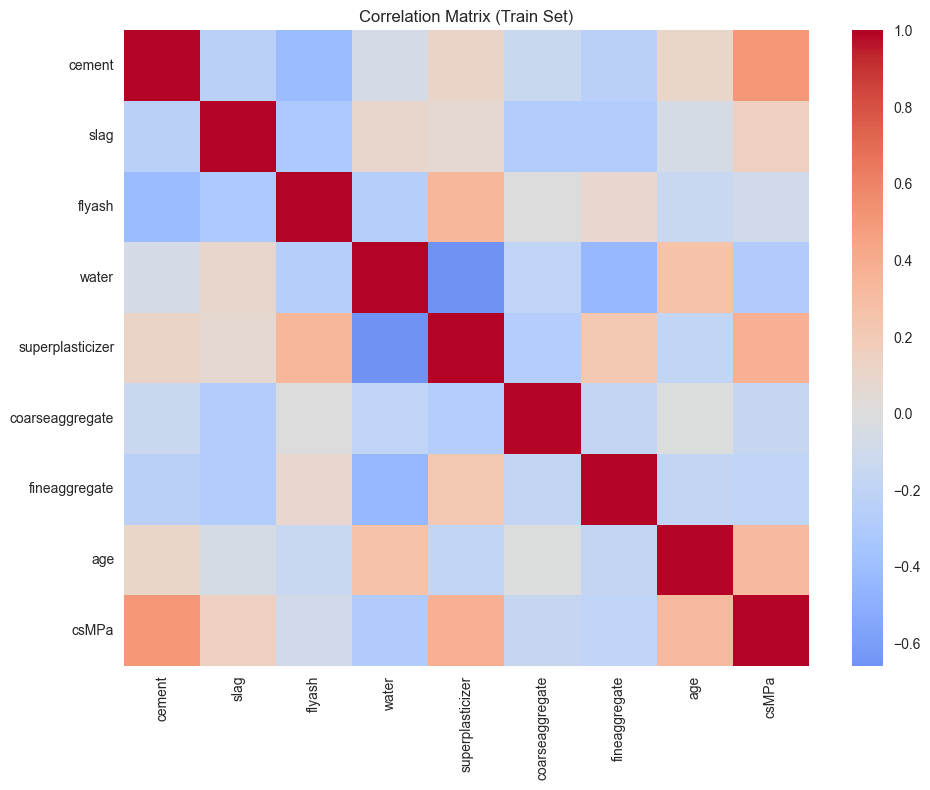

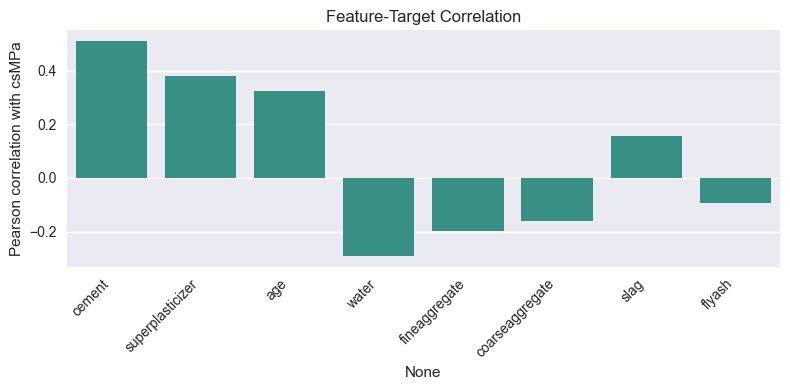

In [33]:
corr_matrix = train_df[feature_cols + [target_col]].corr(numeric_only=True)
corr_with_target = corr_matrix[target_col].drop(target_col).sort_values(
    key=lambda s: s.abs(), ascending=False
)

print("与抗压强度的相关性（按绝对值降序）:")
display(corr_with_target.to_frame("corr_with_csMPa"))

top_k = 5
selected_features_corr = corr_with_target.index[:top_k].tolist()
print(f"\n基于相关性选择的前 {top_k} 个特征: {selected_features_corr}")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=corr_with_target.index, y=corr_with_target.values, color="#2a9d8f")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Pearson correlation with csMPa")
plt.title("Feature-Target Correlation")
plt.tight_layout()
plt.show()

## 2) 主成分分析（PCA）

在标准化后的训练集上进行 PCA，观察累计解释方差，并选取达到 95% 累计解释方差的主成分数。

达到 95% 累计解释方差所需主成分数: 6


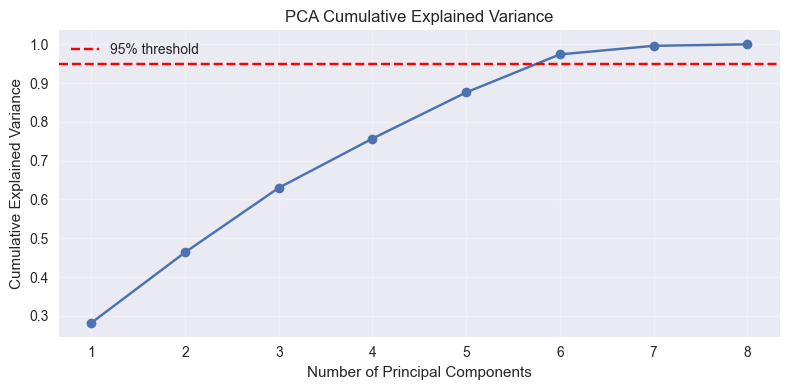

PCA 后训练集维度: (824, 6)
PCA 后测试集维度: (206, 6)


In [34]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_ratio = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)
n_components_95 = int(np.argmax(cum_explained >= 0.95) + 1)

print(f"达到 95% 累计解释方差所需主成分数: {n_components_95}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA 后训练集维度: {X_train_pca.shape}")
print(f"PCA 后测试集维度: {X_test_pca.shape}")

## 3) 线性回归模型（含优化）

对比以下模型：
- 线性回归（全部 8 个特征）
- 线性回归（相关性前 `top_k` 特征）
- 线性回归（PCA 特征）
- 线性回归 + 多项式特征（degree=2）
- 线性回归 + 多项式特征（degree=3）

In [35]:
corr_indices = [feature_cols.index(f) for f in selected_features_corr]
X_train_corr = X_train_scaled[:, corr_indices]
X_test_corr = X_test_scaled[:, corr_indices]

# 基线线性回归：全特征 / 相关性特征 / PCA 特征
lr_full = LinearRegression()
lr_full.fit(X_train_scaled, y_train)
pred_full = lr_full.predict(X_test_scaled)

lr_corr = LinearRegression()
lr_corr.fit(X_train_corr, y_train)
pred_corr = lr_corr.predict(X_test_corr)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
pred_pca = lr_pca.predict(X_test_pca)

# 优化1：线性回归 + 二阶多项式特征
poly2_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ]
)
poly2_model.fit(X_train_raw, y_train)
pred_poly2 = poly2_model.predict(X_test_raw)

# 优化2：线性回归 + 三阶多项式特征
poly3_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ]
)
poly3_model.fit(X_train_raw, y_train)
pred_poly3 = poly3_model.predict(X_test_raw)

results_lr = pd.DataFrame(
    {
        "Model": [
            "Linear Regression (All 8 features)",
            f"Linear Regression (Top {top_k} corr features)",
            "Linear Regression (PCA features)",
            "Linear Regression + Polynomial (degree=2)",
            "Linear Regression + Polynomial (degree=3)",
        ],
        "MSE": [
            mean_squared_error(y_test, pred_full),
            mean_squared_error(y_test, pred_corr),
            mean_squared_error(y_test, pred_pca),
            mean_squared_error(y_test, pred_poly2),
            mean_squared_error(y_test, pred_poly3),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, pred_full)),
            np.sqrt(mean_squared_error(y_test, pred_corr)),
            np.sqrt(mean_squared_error(y_test, pred_pca)),
            np.sqrt(mean_squared_error(y_test, pred_poly2)),
            np.sqrt(mean_squared_error(y_test, pred_poly3)),
        ],
        "R2": [
            r2_score(y_test, pred_full),
            r2_score(y_test, pred_corr),
            r2_score(y_test, pred_pca),
            r2_score(y_test, pred_poly2),
            r2_score(y_test, pred_poly3),
        ],
    }
).sort_values("MSE")

display(results_lr)

,Model,MSE,RMSE,R2
4,Linear Regression + Polynomial (degree=3),35.613144,5.967675,0.849044
3,Linear Regression + Polynomial (degree=2),59.681921,7.725407,0.747022
0,Linear Regression (All 8 features),106.864563,10.337532,0.547025
2,Linear Regression (PCA features),107.022948,10.345190,0.546354
1,Linear Regression (Top 5 corr features),122.898389,11.085955,0.479061


## 4) 神经网络回归（PyTorch）

使用 PyTorch 构建优化版回归神经网络：
- 输入层：8 维
- 隐藏层：128 -> 64 -> 32（BatchNorm + ReLU + Dropout）
- 输出层：1 维
- 损失函数：MSE
- 优化器：AdamW
- 训练策略：验证集、学习率调度（ReduceLROnPlateau）、Early Stopping

Using device: cpu
Epoch   50/1000, Train MSE: 42.1693, Val MSE: 46.5027
Epoch  100/1000, Train MSE: 35.6982, Val MSE: 45.7362
Early stopping at epoch 135

Best Validation MSE: 43.1153
Neural Network Test MSE: 33.4716
Neural Network Test RMSE: 5.7855
Neural Network Test R2: 0.8581


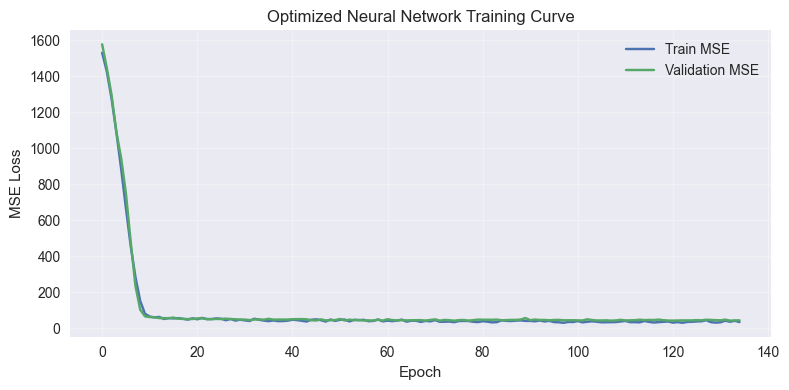

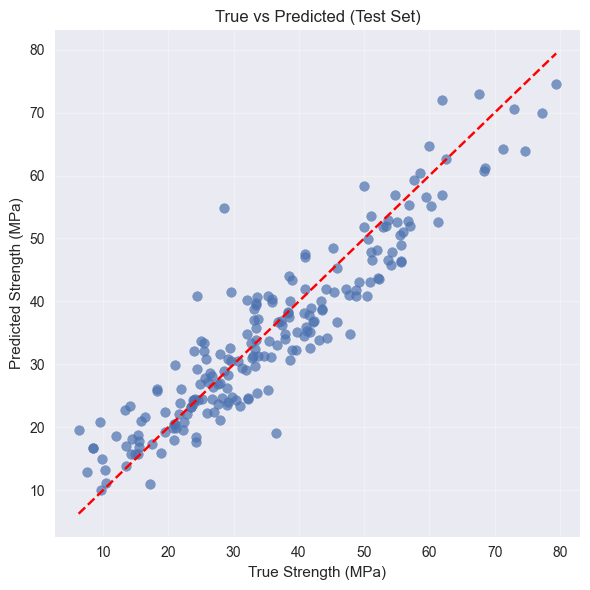

,Model,MSE,RMSE,R2
5,"Neural Network (PyTorch, optimized)",33.471571,5.785462,0.858121
4,Linear Regression + Polynomial (degree=3),35.613144,5.967675,0.849044
3,Linear Regression + Polynomial (degree=2),59.681921,7.725407,0.747022
0,Linear Regression (All 8),106.864563,10.337532,0.547025
2,Linear Regression (PCA),107.022948,10.345190,0.546354
1,Linear Regression (Top 5 corr),122.898389,11.085955,0.479061


In [36]:
import importlib.util
import random

if importlib.util.find_spec("torch") is None:
    raise ImportError("未检测到 PyTorch，请先安装：pip install torch")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 将训练集再划分为训练子集/验证集，用于早停与调参
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=42
)

X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr_tensor, y_tr_tensor),
    batch_size=32,
    shuffle=True,
)

model = nn.Sequential(
    nn.Linear(X_tr_tensor.shape[1], 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.10),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.10),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=20, min_lr=1e-5
)

max_epochs = 1000
early_stop_patience = 60
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0

for epoch in range(max_epochs):
    model.train()
    epoch_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item() * xb.size(0)

    epoch_train_loss /= len(train_loader.dataset)
    train_loss_history.append(epoch_train_loss)

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor.to(device))
        epoch_val_loss = criterion(val_preds, y_val_tensor.to(device)).item()
    val_loss_history.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss - 1e-6:
        best_val_loss = epoch_val_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1:>4}/{max_epochs}, "
            f"Train MSE: {epoch_train_loss:.4f}, Val MSE: {epoch_val_loss:.4f}"
        )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

model.eval()
with torch.no_grad():
    test_pred = model(X_test_tensor.to(device)).cpu().numpy().ravel()

nn_mse = mean_squared_error(y_test, test_pred)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test, test_pred)

print(f"\nBest Validation MSE: {best_val_loss:.4f}")
print(f"Neural Network Test MSE: {nn_mse:.4f}")
print(f"Neural Network Test RMSE: {nn_rmse:.4f}")
print(f"Neural Network Test R2: {nn_r2:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="Train MSE")
plt.plot(val_loss_history, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Optimized Neural Network Training Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.7)
line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--")
plt.xlabel("True Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("True vs Predicted (Test Set)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(
    {
        "Model": [
            "Linear Regression (All 8)",
            f"Linear Regression (Top {top_k} corr)",
            "Linear Regression (PCA)",
            "Linear Regression + Polynomial (degree=2)",
            "Linear Regression + Polynomial (degree=3)",
            "Neural Network (PyTorch, optimized)",
        ],
        "MSE": [
            mean_squared_error(y_test, pred_full),
            mean_squared_error(y_test, pred_corr),
            mean_squared_error(y_test, pred_pca),
            mean_squared_error(y_test, pred_poly2),
            mean_squared_error(y_test, pred_poly3),
            nn_mse,
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, pred_full)),
            np.sqrt(mean_squared_error(y_test, pred_corr)),
            np.sqrt(mean_squared_error(y_test, pred_pca)),
            np.sqrt(mean_squared_error(y_test, pred_poly2)),
            np.sqrt(mean_squared_error(y_test, pred_poly3)),
            nn_rmse,
        ],
        "R2": [
            r2_score(y_test, pred_full),
            r2_score(y_test, pred_corr),
            r2_score(y_test, pred_pca),
            r2_score(y_test, pred_poly2),
            r2_score(y_test, pred_poly3),
            nn_r2,
        ],
    }
).sort_values("MSE")

display(summary_df)

## 5) 实验结论
# 相关性分析
训练集相关性结果显示，csMPa 与 cement 的正相关最高（0.510），其次是 superplasticizer（0.382）和 age（0.326）；负相关最明显的是 water（-0.292）。从绝对值最小看，flyash（-0.095）与强度的线性相关最弱。说明提高水泥用量、减水剂和龄期通常有助于提高强度，而水含量增加通常会降低抗压强度。

# PCA 结论
在 95% 累计解释方差阈值下，从结果看，Linear Regression (PCA) 的性能（MSE 107.02，R2 0.546）与全特征线性回归（MSE 106.86，R2 0.547）非常接近，说明 PCA 保留了大部分有效信息，但对预测性能没有带来明显提升。

# 线性回归优化效果
普通线性回归（全 8 特征）测试集指标为 MSE=106.86，R2=0.547。加入多项式特征后性能显著提升：
degree=2 时 MSE=59.68，R2=0.747（相对基线 MSE 降低约 44.2%，R2 提升约 0.200）；
degree=3 时 MSE=35.61，R2=0.849（相对基线 MSE 降低约 66.7%，R2 提升约 0.302）。
这说明该问题中存在明显非线性关系，多项式特征能有效增强线性模型表达能力。

# 神经网络优化说明
本次神经网络优化采用了：训练/验证集划分、Early Stopping、ReduceLROnPlateau 学习率调度、AdamW、BatchNorm、Dropout 与梯度裁剪。这些策略的目标是降低过拟合并提升泛化能力。
之前的神经网络（v1）和现在（v2）对比：
    MSE         RMSE        R2
v1: 115.7270   10.7576     0.2418
v2：33.471571	5.785462	0.858121
这里其中最大的原因是数据集分布的问题，打乱数据集再取80%就好了非常多

# 最终模型选择
最优模型为 Linear Regression + Polynomial (degree=3)，其 MSE 最低（35.61）且 R2 最高（0.849）。
原因是该模型在保持线性回归可解释性的同时，通过三阶多项式捕捉了配比变量与强度之间的非线性与交互关系，因此在测试集上表现最佳。